# Qualitative Reconstructions

Runs the dense baseline first, then creates qualitative reconstruction figures and PSNR table.


device: cuda
image shape: (1, 1, 32, 32) phase img size: (1, 32, 32) signal shape: (1, 1, 32, 32) n: 1024
run: method=GD, model=deepinv_random, loss=intensity, init=spectral, alpha=4.0, noise=0.0
    shapes: x_true=(1, 1, 32, 32), x_init=(1, 1, 32, 32), y=(1, 4096)
run: method=Accelerated GD, model=deepinv_random, loss=intensity, init=spectral, alpha=4.0, noise=0.0
    shapes: x_true=(1, 1, 32, 32), x_init=(1, 1, 32, 32), y=(1, 4096)
run: method=Adam, model=deepinv_random, loss=intensity, init=spectral, alpha=4.0, noise=0.0
    shapes: x_true=(1, 1, 32, 32), x_init=(1, 1, 32, 32), y=(1, 4096)
run: method=NCG, model=deepinv_random, loss=intensity, init=spectral, alpha=4.0, noise=0.0
    shapes: x_true=(1, 1, 32, 32), x_init=(1, 1, 32, 32), y=(1, 4096)
run: method=L-BFGS, model=deepinv_random, loss=intensity, init=spectral, alpha=4.0, noise=0.0
    shapes: x_true=(1, 1, 32, 32), x_init=(1, 1, 32, 32), y=(1, 4096)


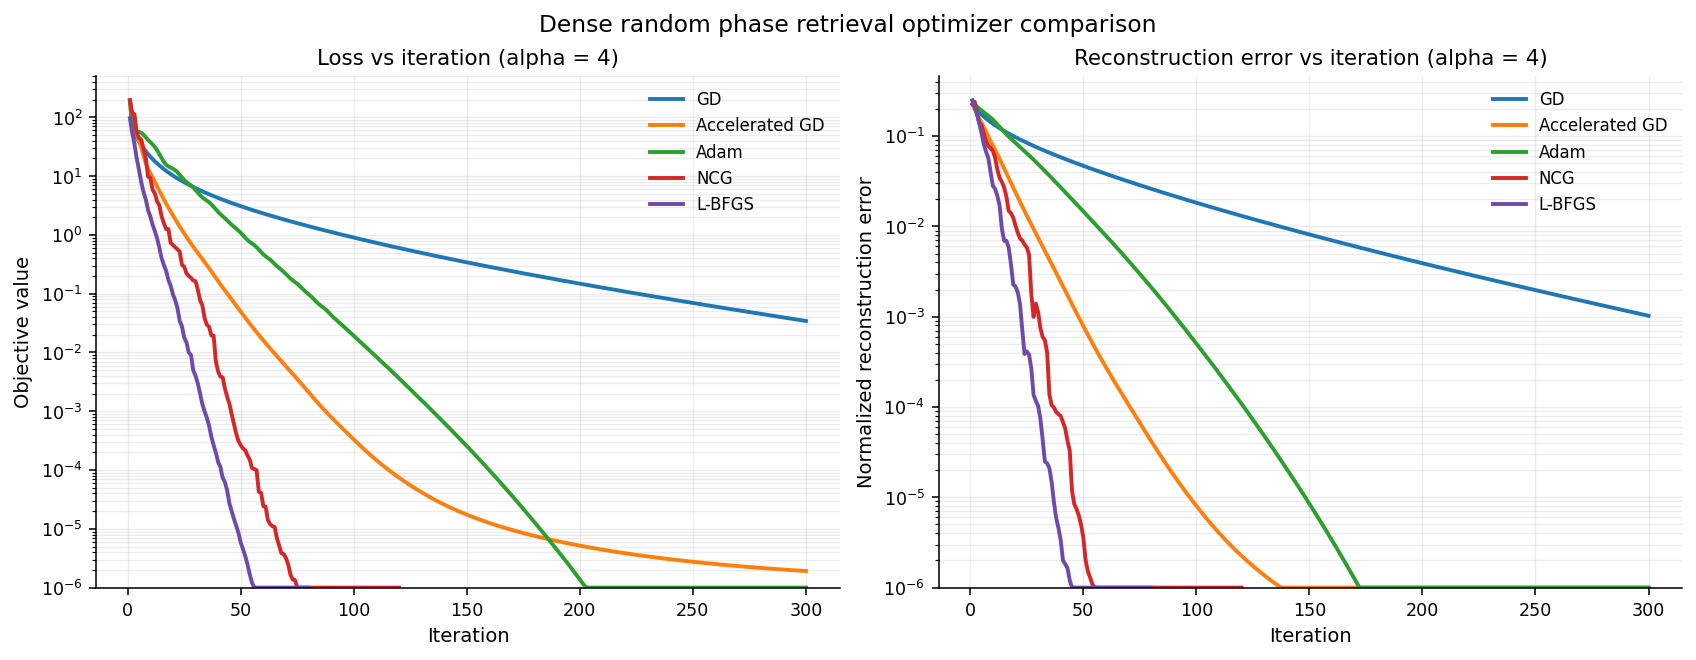

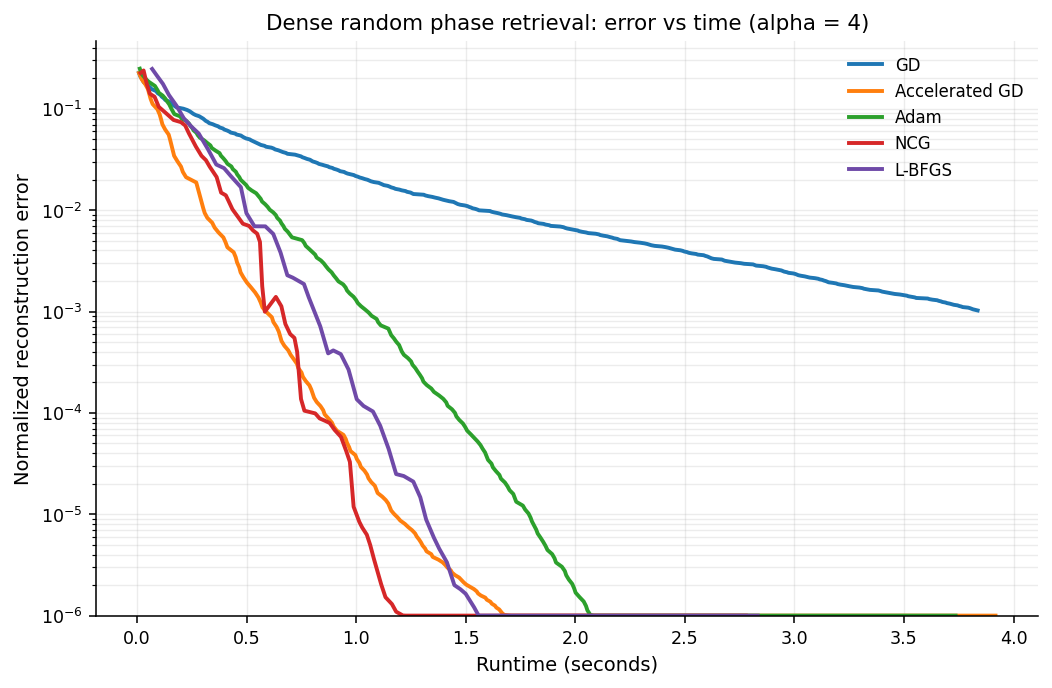

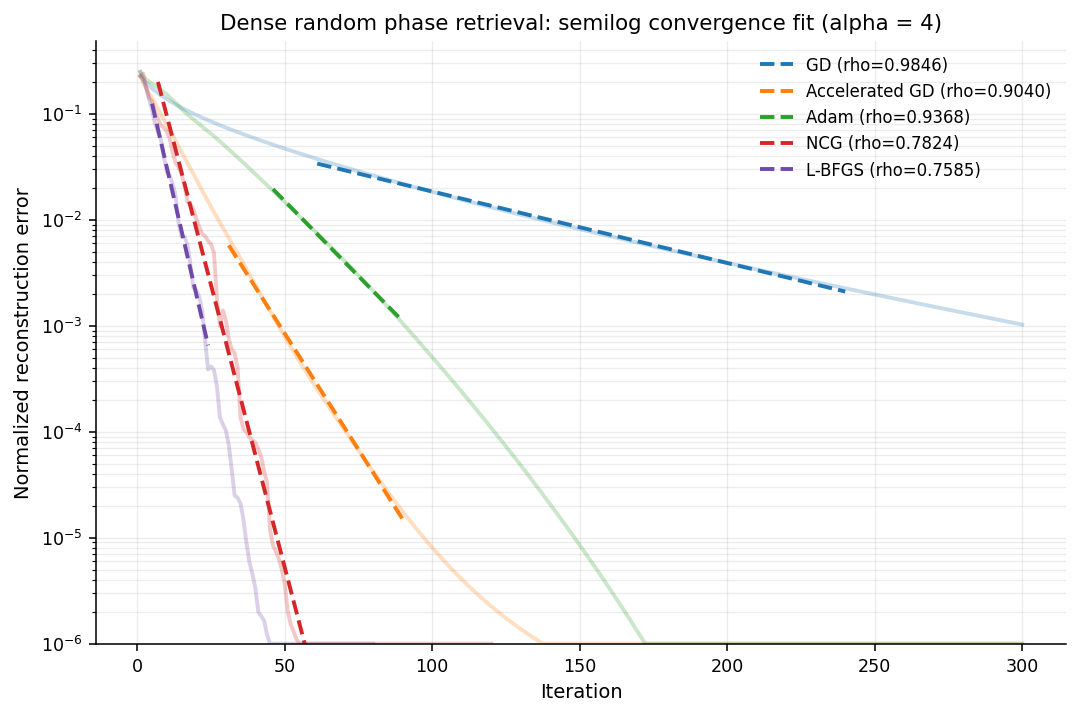

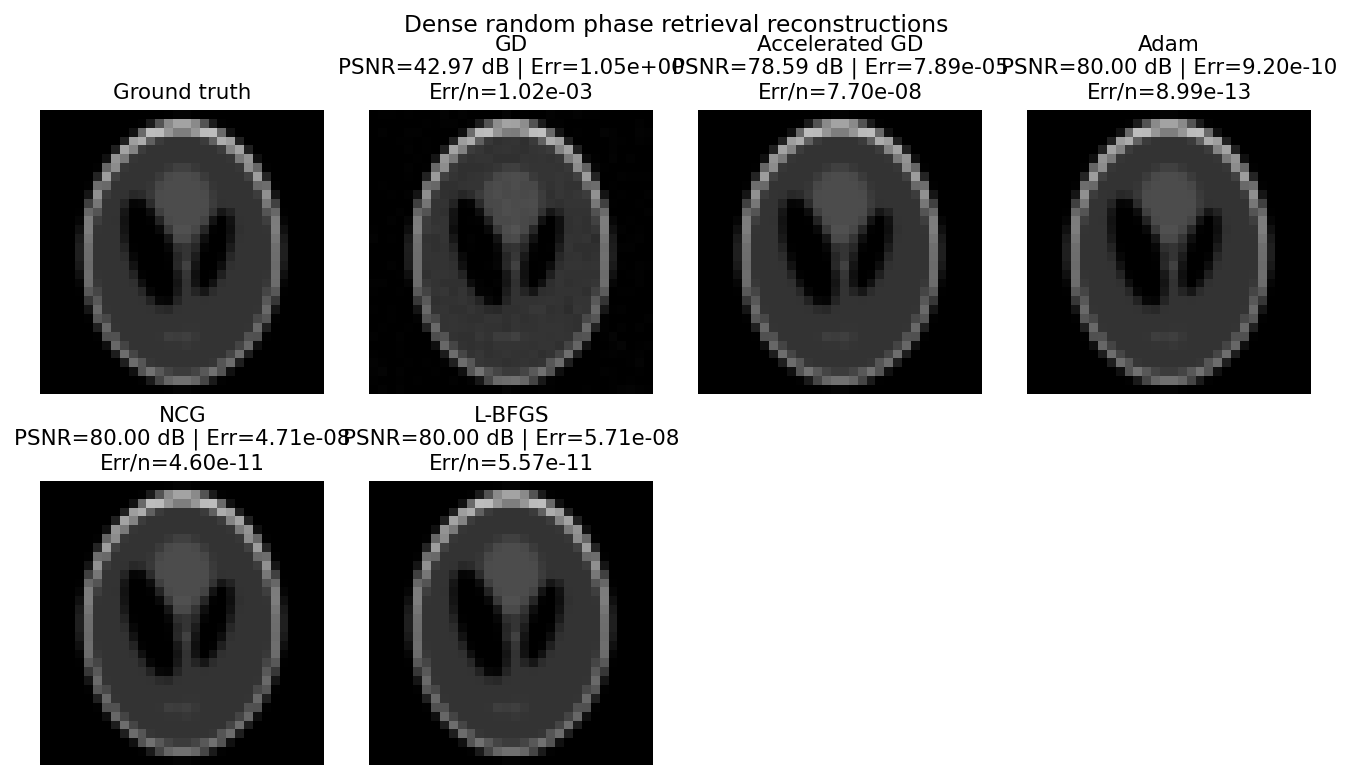

,label,method,psnr_db,final_reconstruction_error,normalized_final_reconstruction_error
0,GD,GD,42.971958,1.049063e+00,1.024476e-03
1,Accelerated GD,Accelerated GD,78.586494,7.889394e-05,7.704486e-08
2,Adam,Adam,79.999977,9.201105e-10,8.985454e-13
3,NCG,NCG,79.998978,4.711270e-08,4.600850e-11
4,L-BFGS,L-BFGS,79.998703,5.705259e-08,5.571542e-11


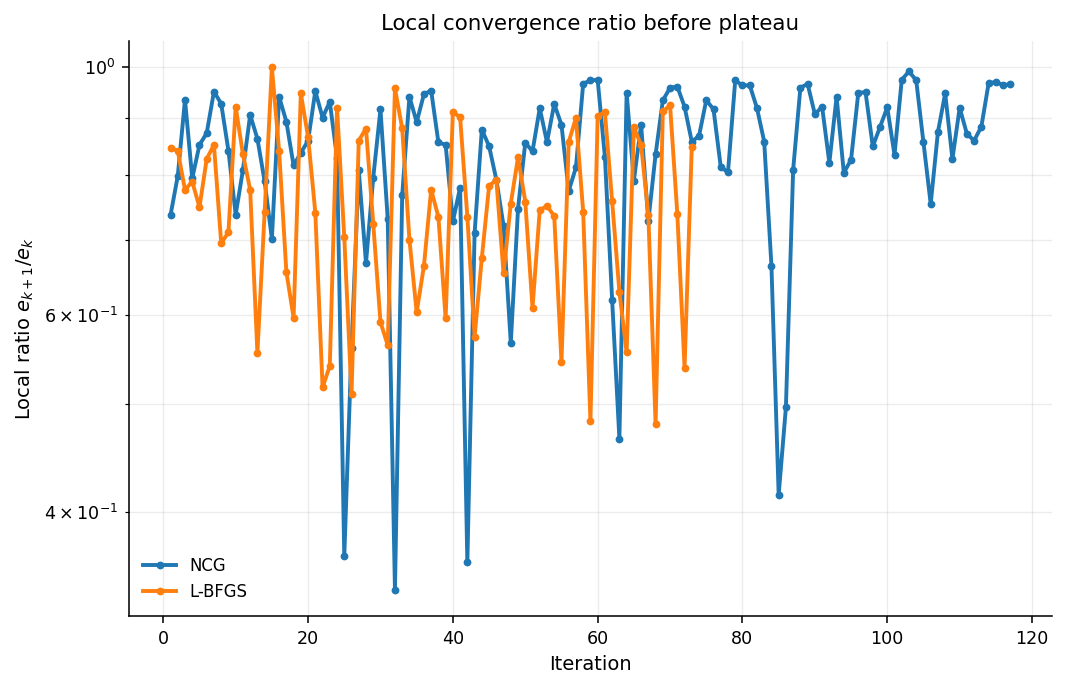

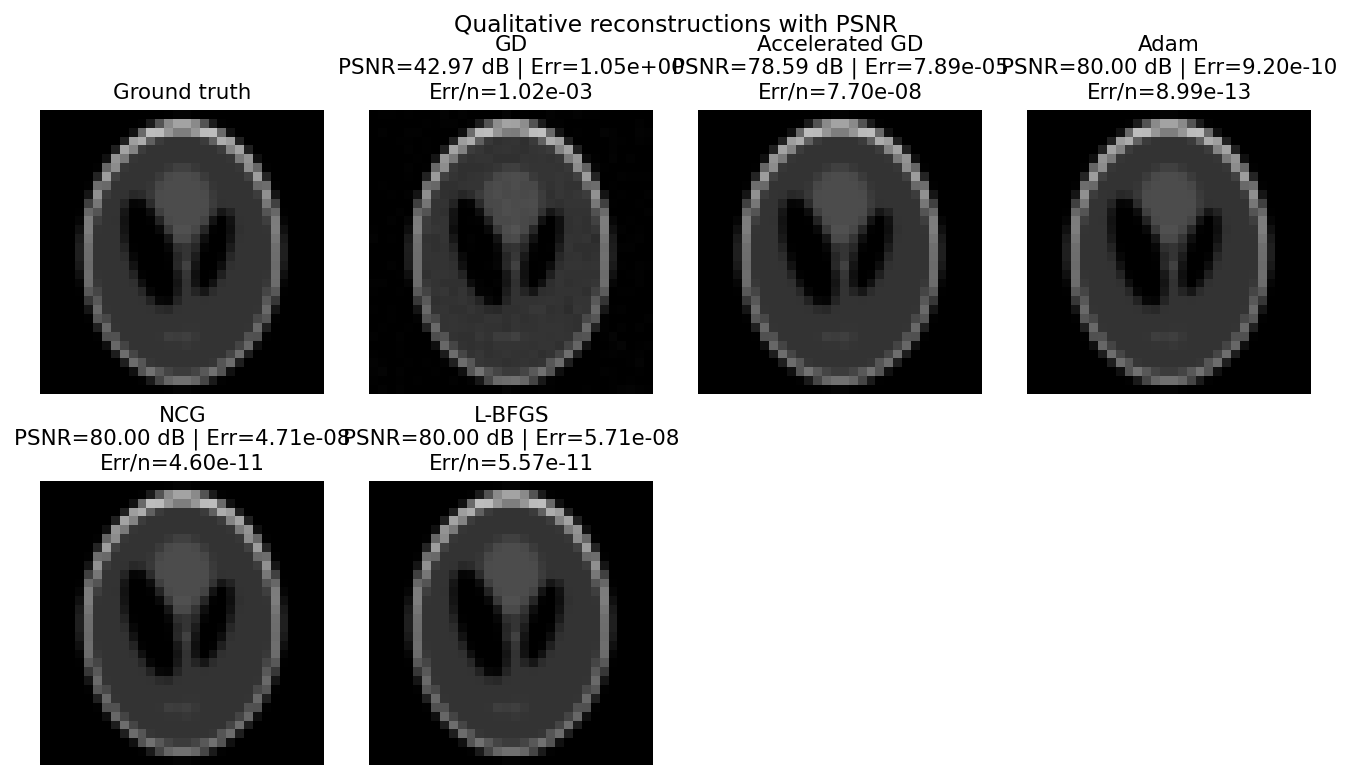

,label,method,psnr_db,final_reconstruction_error,normalized_final_reconstruction_error
0,GD,GD,42.971958,1.049063e+00,1.024476e-03
1,Accelerated GD,Accelerated GD,78.586494,7.889394e-05,7.704486e-08
2,Adam,Adam,79.999977,9.201105e-10,8.985454e-13
3,NCG,NCG,79.998978,4.711270e-08,4.600850e-11
4,L-BFGS,L-BFGS,79.998703,5.705259e-08,5.571542e-11


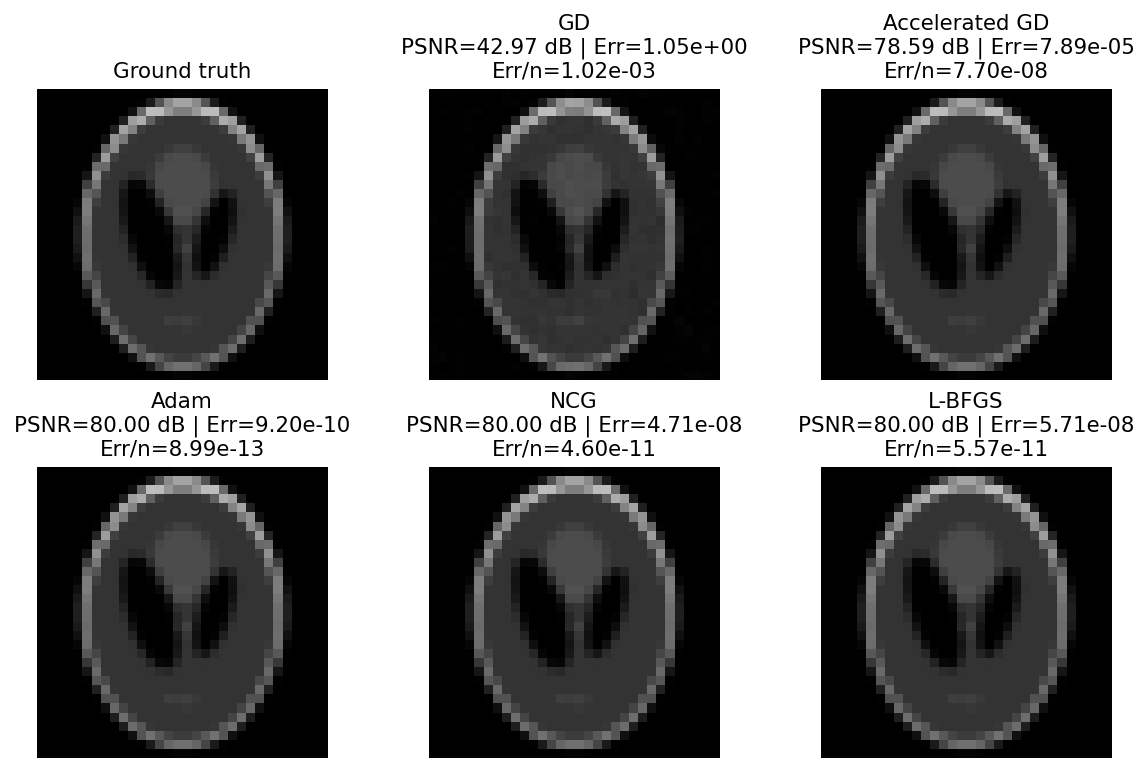

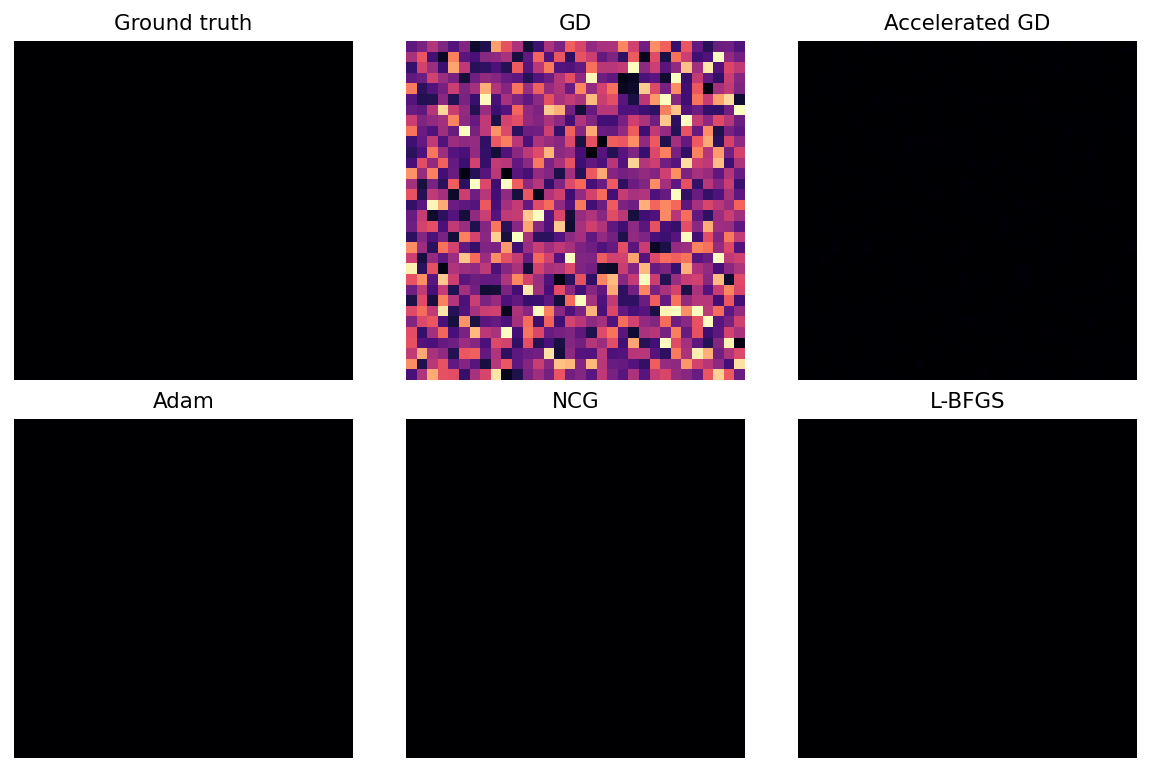

,label,method,alpha,model,loss,initialization,noise_level,final_reconstruction_error,normalized_final_reconstruction_error,psnr_db
0,GD,GD,4.0,deepinv_random,intensity,spectral,0.0,1.049063e+00,1.024476e-03,42.971958
1,Accelerated GD,Accelerated GD,4.0,deepinv_random,intensity,spectral,0.0,7.889394e-05,7.704486e-08,78.586494
2,Adam,Adam,4.0,deepinv_random,intensity,spectral,0.0,9.201105e-10,8.985454e-13,79.999977
3,NCG,NCG,4.0,deepinv_random,intensity,spectral,0.0,4.711270e-08,4.600850e-11,79.998978
4,L-BFGS,L-BFGS,4.0,deepinv_random,intensity,spectral,0.0,5.705259e-08,5.571542e-11,79.998703


In [5]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "report_experiments_split").exists():
        sys.path.insert(0, str(candidate))
        break

from report_experiments_split import config, problem, metrics, runners, plotting, common, experiment_configs
import importlib
importlib.reload(config)
importlib.reload(problem)
importlib.reload(metrics)
importlib.reload(runners)
importlib.reload(plotting)
importlib.reload(common)
importlib.reload(experiment_configs)
from report_experiments_split.experiments import dense_random_optimizer_comparison

importlib.reload(dense_random_optimizer_comparison)

dense_outputs = dense_random_optimizer_comparison.run()
dense_runs = dense_outputs["runs"]
psnr_qualitative_df = plotting.plot_reconstructions_with_psnr(
    dense_runs,
    "qualitative_reconstructions_psnr",
    "Qualitative reconstructions with PSNR",
    label_keys=("method",),
)
plotting.plot_qualitative(dense_runs)
psnr_qualitative_df
